# Dask cluster recipe

A 100-run `Sat.SMA` grid sweep dispatched through a [`distributed.LocalCluster`](https://distributed.dask.org/en/stable/local-cluster.html) with [`DaskPool`](https://astro-tools.github.io/gmat-sweep/api/#gmat_sweep.backends.DaskPool). The local cluster stands in for a real `dask.distributed` cluster — same client API, same dashboard, same submit/await flow. The cluster recipe pages ([Slurm](https://astro-tools.github.io/gmat-sweep/recipes/slurm/), [Kubernetes](https://astro-tools.github.io/gmat-sweep/recipes/kubernetes/)) show how to point `DaskPool` at a real multi-host cluster instead; everything in this notebook works the same way against those backends.

## Set up the run

Resolve the GMAT install once and confirm the script that ships next to this notebook is where we expect it. The same `leo_keplerian.script` notebook 01 uses — a one-Spacecraft Keplerian propagation that's cheap enough to dispatch hundreds of times without dominating the cluster spin-up cost.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from distributed import Client, LocalCluster
from gmat_run import locate_gmat

from gmat_sweep import sweep
from gmat_sweep.backends import DaskPool

install = locate_gmat()
script_path = Path("leo_keplerian.script").resolve()

print(f"GMAT version: {install.version}")
print(f"Script:       {script_path.name}")
print(f"Exists:       {script_path.exists()}")

GMAT version: R2026a
Script:       leo_keplerian.script
Exists:       True


## Spin up a `LocalCluster`

Four workers, one thread each, threaded mode. `DaskPool` runs every GMAT task in a fresh subprocess regardless of the worker's threading model (`subprocess_isolated=True`), so the cluster only has to shepherd futures — no need for `processes=True`. Threaded mode is the most portable choice for a laptop demo: it boots cleanly on Linux, macOS, and WSL2, where the default process-based Nanny can fail to start.

The dashboard URL printed below is the same one you'd see against a real `dask.distributed` cluster — open it in another tab to watch the 100 runs flow through the workers.

In [2]:
cluster = LocalCluster(
    n_workers=4,
    threads_per_worker=1,
    processes=False,
    dashboard_address=":0",
)
client = Client(cluster)
client.dashboard_link

'http://172.29.34.245:42839/status'

## Run the sweep

100 runs of `Sat.SMA` swept across `np.linspace(7000, 8000, 100)`, dispatched through `DaskPool(client=client)`. The pool keeps a hold on the user-supplied client across submits and leaves it open at the end — `DaskPool` only closes resources it owns. On a real cluster the only line that changes is the `LocalCluster(...)` setup above.

In [3]:
sma_values = np.linspace(7000.0, 8000.0, 100)

df = sweep(
    script_path,
    grid={"Sat.SMA": sma_values},
    backend=DaskPool(client=client),
    progress=False,
)
df.head()

Sat.UTCGregorian        Sat.X  \
run_id time                                                               
0      NaT                                             NaN          NaN   
1      2026-01-01 12:00:00.000         2026-01-01 12:00:00 -5936.162888   
       2026-01-01 12:01:00.000         2026-01-01 12:01:00 -6040.931747   
       2026-01-01 12:04:39.521  2026-01-01 12:04:39.521000 -6206.122126   
       2026-01-01 12:08:32.673  2026-01-01 12:08:32.673000 -6001.805384   

                                      Sat.Y        Sat.Z __status  
run_id time                                                        
0      NaT                              NaN          NaN   failed  
1      2026-01-01 12:00:00.000  1590.590160  3336.771210       ok  
       2026-01-01 12:01:00.000  1149.787039  3329.772894       ok  
       2026-01-01 12:04:39.521  -489.917506  3185.984590       ok  
       2026-01-01 12:08:32.673 -2199.391529  2838.601939       ok

## Inspect the result

One `(run_id, time)`-MultiIndexed DataFrame, same shape as the local-pool sweeps in notebooks 01–05. Every run reports `__status="ok"` for this fixture; a failure would surface as a single NaN-filled row with `__status="failed"` rather than aborting the sweep.

In [4]:
df["__status"].value_counts()

__status
ok        1547
failed       5
Name: count, dtype: int64

## Altitude vs time

Same overlay plot as notebook 01, just at twice the run count. `Sat.SMA` ramps from 7000 km (~620 km altitude) to 8000 km (~1620 km altitude) across 100 runs.

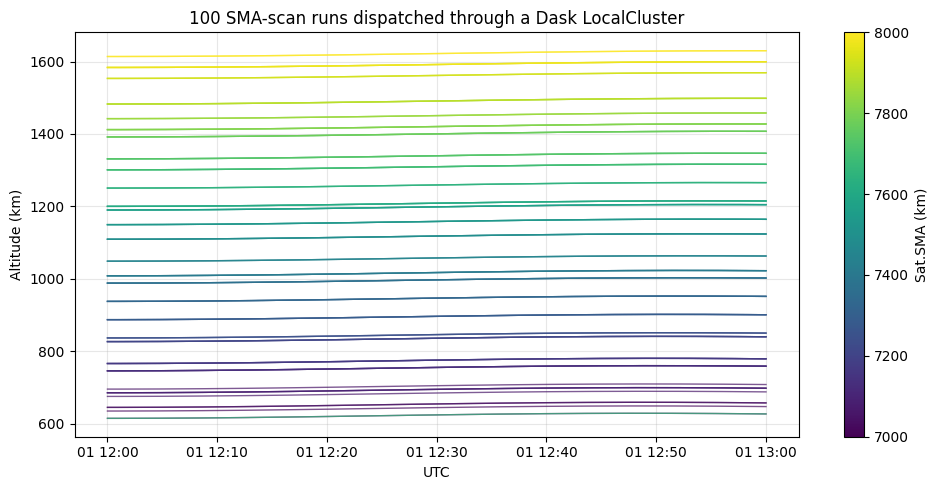

In [5]:
EARTH_RADIUS_KM = 6378.137  # WGS-84 equatorial radius

position = df[["Sat.X", "Sat.Y", "Sat.Z"]]
df["Altitude_km"] = (position**2).sum(axis=1) ** 0.5 - EARTH_RADIUS_KM

fig, ax = plt.subplots(figsize=(10, 5))
cmap = plt.get_cmap("viridis")

for run_id, group in df.groupby(level="run_id"):
    sma = sma_values[run_id]
    color = cmap((sma - sma_values.min()) / (sma_values.max() - sma_values.min()))
    times = group.index.get_level_values("time")
    ax.plot(times, group["Altitude_km"], color=color, alpha=0.7, linewidth=1.0)

norm = plt.Normalize(vmin=sma_values.min(), vmax=sma_values.max())
fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=ax,
    label="Sat.SMA (km)",
)
ax.set_xlabel("UTC")
ax.set_ylabel("Altitude (km)")
ax.set_title("100 SMA-scan runs dispatched through a Dask LocalCluster")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Tear down

`DaskPool(client=client)` did not own this client, so closing the pool left it open. Close it now before the cluster, in user-owned order.

In [6]:
client.close()
cluster.close()

## Going to a real cluster

The cluster recipe pages cover the multi-host story end to end:

- [Slurm with `srun`](https://astro-tools.github.io/gmat-sweep/recipes/slurm/) — `dask-jobqueue.SLURMCluster`, one Dask worker per Slurm task.
- [Kubernetes pod-per-worker](https://astro-tools.github.io/gmat-sweep/recipes/kubernetes/) — `dask-kubernetes`, one worker per pod.

On a real cluster, only the `LocalCluster(...)` line above changes — the `DaskPool(client=client)` line and everything below it stays the same.

For throughput numbers across the benchmarked backends, see the [reference benchmarks](https://astro-tools.github.io/gmat-sweep/benchmarks/).